# H. Análisis Exploratorio de Datos (EDA) orientado a decisiones

**Proyecto:** predicción de ingreso anual superior a USD 50K — Adult Census Income (1994)

Este notebook reorganiza y profundiza únicamente los análisis técnicamente relevantes identificados en `Proyecto_Final_Mod6.ipynb`. No busca acumular gráficos: cada bloque termina con una decisión explícita de **limpieza, ingeniería de variables, modelado o negocio**.

> Pregunta rectora: **¿Qué decisión cambia como consecuencia de este resultado?**

## Decisiones que se validarán

1. Normalizar el objetivo y los faltantes antes del análisis.
2. Eliminar duplicados antes de separar entrenamiento y prueba.
3. Evitar imputar con estadísticas calculadas sobre todo el dataset; la imputación pertenece al pipeline.
4. Conservar `education-num` y descartar `education` por redundancia exacta.
5. Tratar el desbalance mediante partición estratificada y métricas adecuadas.
6. Transformar variables monetarias sesgadas y añadir indicadores de presencia de capital.
7. Manejar categorías raras y categorías no vistas sin crear columnas frágiles.
8. Evaluar de forma conjunta las variables familiares relacionadas, sin eliminarlas solo por asociación.
9. No eliminar valores extremos válidos únicamente por una regla estadística.


## 1. Preparación reproducible

Se obtiene el mismo dataset usado en el proyecto original. La limpieza aplicada aquí se limita a normalizar representaciones, sin aprender parámetros de imputación a partir del conjunto completo.


In [ ]:
%pip install -q ucimlrepo

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.3f}'.format)
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42


In [2]:
from ucimlrepo import fetch_ucirepo

adult = fetch_ucirepo(id=2)
df_raw = pd.concat([adult.data.features, adult.data.targets], axis=1)

print(f'Dimensiones originales: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
display(df_raw.head(3))


Dimensiones originales: 48,842 filas × 15 columnas


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


In [3]:
# Normalización mínima y explícita
df = df_raw.copy()

text_cols = df.select_dtypes(include=['object', 'string']).columns
for col in text_cols:
    df[col] = df[col].astype('string').str.strip()
    df[col] = df[col].replace({'?': pd.NA, '': pd.NA})

df['income'] = df['income'].str.rstrip('.').map({'<=50K': 0, '>50K': 1}).astype('Int64')

assert set(df['income'].dropna().unique()) == {0, 1}
assert df['income'].notna().all()
print('Objetivo normalizado: 0 = <=50K; 1 = >50K')


Objetivo normalizado: 0 = <=50K; 1 = >50K


## 2. Calidad de datos que sí cambia el pipeline

### 2.1 Duplicados y faltantes

Los duplicados pueden terminar a ambos lados de la partición y producir una evaluación optimista. Los faltantes requieren una decisión distinta: su imputación debe aprenderse solo con entrenamiento.


In [4]:
duplicados = int(df.duplicated().sum())
nulos = df.isna().sum().loc[lambda s: s.gt(0)].sort_values(ascending=False)

resumen_calidad = pd.DataFrame({
    'faltantes': nulos,
    'porcentaje': (100 * nulos / len(df)).round(2)
})

print(f'Duplicados exactos antes de imputar: {duplicados:,}')
display(resumen_calidad)


Duplicados exactos antes de imputar: 52


,faltantes,porcentaje
occupation,2809,5.750
workclass,2799,5.730
native-country,857,1.750


**Decisión de limpieza/modelado**

- Eliminar duplicados **antes** de `train_test_split` para reducir fuga entre conjuntos.
- No imputar todavía. La moda de cada columna se aprenderá dentro de un pipeline usando únicamente el conjunto de entrenamiento.
- Mantener un indicador de ausencia para `workclass`, `occupation` y `native-country`, porque “dato no informado” puede contener señal y la moda por sí sola la borraría.


In [5]:
df = df.drop_duplicates().reset_index(drop=True)

missing_cols = ['workclass', 'occupation', 'native-country']
for col in missing_cols:
    df[f'{col}__missing'] = df[col].isna().astype('int8')

print(f'Filas después de eliminar duplicados: {len(df):,}')
print(f'Duplicados restantes: {df.duplicated().sum()}')


Filas después de eliminar duplicados: 48,790
Duplicados restantes: 0


### 2.2 ¿La ausencia de datos cambia la tasa del objetivo?

La comparación usa diferencia en puntos porcentuales. No pretende probar causalidad; determina si conviene conservar el patrón de ausencia como variable.


In [6]:
filas = []
base = df['income'].mean()
for col in missing_cols:
    indicador = df[col].isna()
    for estado, mascara in [('presente', ~indicador), ('faltante', indicador)]:
        filas.append({
            'variable': col,
            'estado': estado,
            'n': int(mascara.sum()),
            'tasa_>50K': df.loc[mascara, 'income'].mean(),
            'diferencia_pp_vs_total': 100 * (df.loc[mascara, 'income'].mean() - base)
        })

missing_target = pd.DataFrame(filas)
display(missing_target.style.format({'tasa_>50K': '{:.2%}', 'diferencia_pp_vs_total': '{:+.2f}'}))


,variable,estado,n,tasa_>50K,diferencia_pp_vs_total
0,workclass,presente,45995,24.82%,+0.88
1,workclass,faltante,2795,9.48%,-14.46
2,occupation,presente,45985,24.83%,+0.88
3,occupation,faltante,2805,9.45%,-14.49
4,native-country,presente,47934,23.91%,-0.03
5,native-country,faltante,856,25.70%,+1.76


**Decisión de ingeniería de variables**

Conservar los tres indicadores `__missing` y realizar imputación por moda dentro del pipeline. Si en una ejecución la tasa del objetivo entre “faltante” y “presente” resulta prácticamente igual, la utilidad del indicador se confirmará posteriormente mediante validación cruzada, no por intuición.


## 3. Variable objetivo: desbalance y criterio de éxito

La clase de interés (`income = 1`) representa aproximadamente una cuarta parte de los casos. Por eso la exactitud aislada puede premiar un modelo que casi siempre prediga la clase mayoritaria.


In [7]:
target_summary = pd.DataFrame({
    'n': df['income'].value_counts().sort_index(),
    'proporción': df['income'].value_counts(normalize=True).sort_index()
})
display(target_summary.style.format({'proporción': '{:.2%}'}))

majority_accuracy = df['income'].value_counts(normalize=True).max()
ratio = df['income'].value_counts().max() / df['income'].value_counts().min()
print(f'Exactitud trivial de predecir siempre la mayoría: {majority_accuracy:.2%}')
print(f'Relación mayoría:minoría: {ratio:.2f}:1')


,n,proporción
income,,
0,37109,76.06%
1,11681,23.94%


Exactitud trivial de predecir siempre la mayoría: 76.06%
Relación mayoría:minoría: 3.18:1


In [8]:
X = df.drop(columns='income')
y = df['income'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

display(pd.DataFrame({
    'conjunto': ['total', 'train', 'test'],
    'filas': [len(y), len(y_train), len(y_test)],
    'tasa_>50K': [y.mean(), y_train.mean(), y_test.mean()]
}).style.format({'tasa_>50K': '{:.2%}'}))


,conjunto,filas,tasa_>50K
0,total,48790,23.94%
1,train,39032,23.94%
2,test,9758,23.94%


**Decisión de modelado/negocio**

- Usar partición estratificada.
- Reportar como mínimo `recall`, `precision`, `F1`, `ROC-AUC`, `PR-AUC` y matriz de confusión; no aprobar un modelo solo por `accuracy`.
- Probar `class_weight='balanced'` dentro de validación cruzada.
- Elegir el umbral según el costo de falsos negativos y falsos positivos. Si el fin es identificar prospectos >50K, el `recall` de la clase 1 tiene prioridad, sujeto a una precisión mínima acordada con negocio.


## 4. Redundancia: `education` y `education-num`

El notebook original identificó que ambas columnas contienen la misma información en distinta representación. Aquí se verifica el mapeo uno-a-uno.


In [9]:
edu_map = (
    df.groupby('education', dropna=False)['education-num']
      .agg(['nunique', 'min', 'max', 'size'])
      .sort_values('min')
)
display(edu_map)

assert edu_map['nunique'].max() == 1
print('Cada categoría education corresponde a un único education-num.')


,nunique,min,max,size
education,,,,
Preschool,1,1,1,81
1st-4th,1,2,2,245
5th-6th,1,3,3,507
7th-8th,1,4,4,954
9th,1,5,5,756
10th,1,6,6,1389
11th,1,7,7,1812
12th,1,8,8,655
HS-grad,1,9,9,15770


Cada categoría education corresponde a un único education-num.


**Decisión de ingeniería de variables**

Descartar `education` y conservar `education-num`: evita duplicar señal, reduce dimensionalidad tras one-hot encoding y mantiene el orden educativo. Esta decisión debe ejecutarse dentro de la preparación de variables, no después de entrenar.


## 5. Variables numéricas: forma, ceros y extremos válidos

Un resumen compacto responde tres preguntas: ¿hay asimetría?, ¿dominan los ceros?, ¿los valores están fuera del dominio documentado?


In [10]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

numeric_summary = pd.DataFrame({
    'mínimo': df[numeric_cols].min(),
    'mediana': df[numeric_cols].median(),
    'media': df[numeric_cols].mean(),
    'p99': df[numeric_cols].quantile(.99),
    'máximo': df[numeric_cols].max(),
    '% ceros': 100 * df[numeric_cols].eq(0).mean(),
    'asimetría': df[numeric_cols].skew()
})
display(numeric_summary.round(2))


,mínimo,mediana,media,p99,máximo,% ceros,asimetría
age,17,37.000,38.650,74.000,90,0.000,0.560
fnlwgt,12285,"178,138.500","189,669.000","509,514.190",1490400,0.000,1.440
education-num,1,10.000,10.080,16.000,16,0.000,-0.310
capital-gain,0,0.000,"1,080.220","15,024.000",99999,91.730,11.890
capital-loss,0,0.000,87.600,"2,001.000",4356,95.320,4.570
hours-per-week,1,40.000,40.430,80.000,99,0.000,0.240


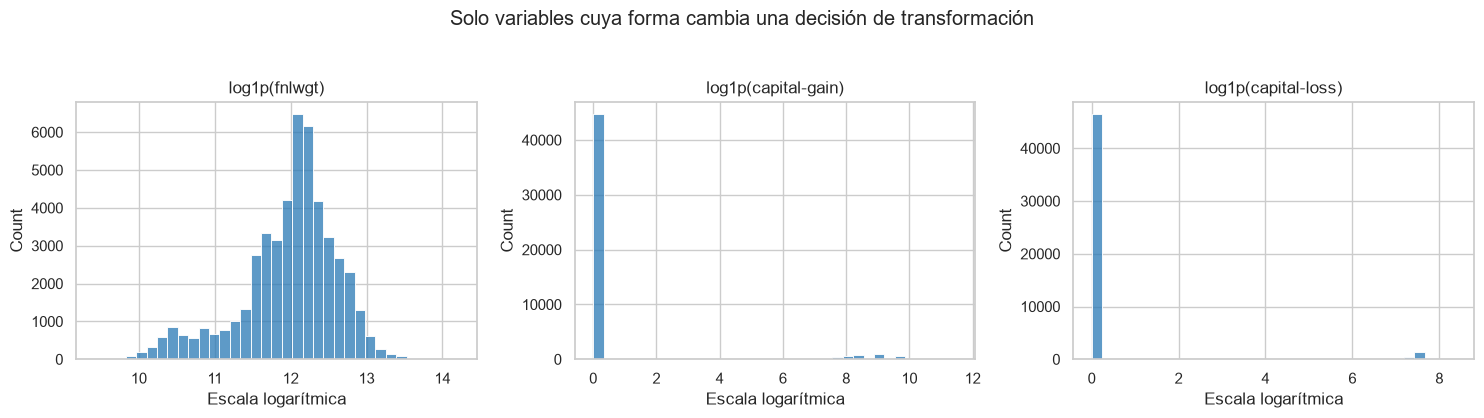

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['fnlwgt', 'capital-gain', 'capital-loss']):
    sns.histplot(np.log1p(df[col]), bins=35, ax=ax, color='#2878B5')
    ax.set_title(f'log1p({col})')
    ax.set_xlabel('Escala logarítmica')

fig.suptitle('Solo variables cuya forma cambia una decisión de transformación', y=1.04)
plt.tight_layout()
plt.show()


In [12]:
rangos = {
    'age': (17, 90),
    'education-num': (1, 16),
    'capital-gain': (0, 99999),
    'capital-loss': (0, 4356),
    'hours-per-week': (1, 99)
}

checks = []
for col, (low, high) in rangos.items():
    fuera = (~df[col].between(low, high)).sum()
    checks.append({'variable': col, 'rango esperado': f'[{low}, {high}]', 'fuera de rango': int(fuera)})
display(pd.DataFrame(checks))


,variable,rango esperado,fuera de rango
0,age,"[17, 90]",0
1,education-num,"[1, 16]",0
2,capital-gain,"[0, 99999]",0
3,capital-loss,"[0, 4356]",0
4,hours-per-week,"[1, 99]",0


**Decisión de limpieza e ingeniería**

- No eliminar registros válidos de `hours-per-week`, `age` o montos de capital solo porque el IQR los marque como atípicos. El rango de negocio prevalece sobre una regla mecánica.
- Aplicar `log1p` a `capital-gain`, `capital-loss` y `fnlwgt` cuando el modelo sea sensible a escala/asimetría.
- Crear `has_capital_gain` y `has_capital_loss`: distinguen la presencia del evento del tamaño del monto en variables con más de 90% de ceros.
- Comparar mediante validación cruzada la transformación para modelos de árboles, que normalmente no la necesitan; conservarla como parte del pipeline para modelos lineales.


In [13]:
for col in ['capital-gain', 'capital-loss']:
    df[f'has_{col.replace("-", "_")}'] = (df[col] > 0).astype('int8')
    df[f'log1p_{col.replace("-", "_")}'] = np.log1p(df[col])

df['log1p_fnlwgt'] = np.log1p(df['fnlwgt'])
display(df[['capital-gain', 'has_capital_gain', 'log1p_capital_gain',
            'capital-loss', 'has_capital_loss', 'log1p_capital_loss']].head())


,capital-gain,has_capital_gain,log1p_capital_gain,capital-loss,has_capital_loss,log1p_capital_loss
0,2174,1,7.685,0,0,0.000
1,0,0,0.000,0,0,0.000
2,0,0,0.000,0,0,0.000
3,0,0,0.000,0,0,0.000
4,0,0,0.000,0,0,0.000


## 6. Señal frente al objetivo: magnitud y soporte

Una tasa alta con muy pocos casos puede ser inestable. Por eso se muestran simultáneamente tasa de >50K, cantidad de registros y diferencia respecto de la tasa base.


In [14]:
def target_rate_table(data, feature, target='income', min_support=100):
    out = (data.groupby(feature, dropna=False)[target]
               .agg(n='size', tasa_50k='mean')
               .reset_index())
    out['lift_vs_total'] = out['tasa_50k'] / data[target].mean()
    out['soporte_suficiente'] = out['n'] >= min_support
    return out.sort_values(['tasa_50k', 'n'], ascending=False)

for feature in ['occupation', 'marital-status', 'workclass']:
    print()
    print(feature)
    display(target_rate_table(df, feature).head(15).style.format({
        'tasa_50k': '{:.2%}', 'lift_vs_total': '{:.2f}×'
    }))



occupation


,occupation,n,tasa_50k,lift_vs_total,soporte_suficiente
3,Exec-managerial,6082,47.78%,2.00×,True
9,Prof-specialty,6165,45.13%,1.88×,True
1,Armed-Forces,15,33.33%,1.39×,False
10,Protective-serv,982,31.36%,1.31×,True
12,Tech-support,1445,29.07%,1.21×,True
11,Sales,5501,26.81%,1.12×,True
2,Craft-repair,6102,22.65%,0.95×,True
13,Transport-moving,2355,20.42%,0.85×,True
0,Adm-clerical,5606,13.70%,0.57×,True
6,Machine-op-inspct,3017,12.30%,0.51×,True



marital-status


,marital-status,n,tasa_50k,lift_vs_total,soporte_suficiente
2,Married-civ-spouse,22366,44.61%,1.86×,True
1,Married-AF-spouse,37,37.84%,1.58×,False
0,Divorced,6630,10.12%,0.42×,True
3,Married-spouse-absent,627,9.25%,0.39×,True
6,Widowed,1518,8.43%,0.35×,True
5,Separated,1530,6.47%,0.27×,True
4,Never-married,16082,4.56%,0.19×,True



workclass


,workclass,n,tasa_50k,lift_vs_total,soporte_suficiente
4,Self-emp-inc,1694,55.37%,2.31×,True
0,Federal-gov,1432,39.18%,1.64×,True
1,Local-gov,3136,29.56%,1.23×,True
5,Self-emp-not-inc,3861,27.89%,1.17×,True
6,State-gov,1981,26.75%,1.12×,True
3,Private,33860,21.80%,0.91×,True
7,Without-pay,21,9.52%,0.40×,False
8,,2795,9.48%,0.40×,True
2,Never-worked,10,0.00%,0.00×,False


In [15]:
capital_effect = pd.DataFrame({
    'segmento': ['Sin ganancia', 'Con ganancia', 'Sin pérdida', 'Con pérdida'],
    'n': [
        (df['capital-gain'] == 0).sum(), (df['capital-gain'] > 0).sum(),
        (df['capital-loss'] == 0).sum(), (df['capital-loss'] > 0).sum()
    ],
    'tasa_>50K': [
        df.loc[df['capital-gain'] == 0, 'income'].mean(),
        df.loc[df['capital-gain'] > 0, 'income'].mean(),
        df.loc[df['capital-loss'] == 0, 'income'].mean(),
        df.loc[df['capital-loss'] > 0, 'income'].mean()
    ]
})
display(capital_effect.style.format({'tasa_>50K': '{:.2%}'}))


,segmento,n,tasa_>50K
0,Sin ganancia,44755,20.53%
1,Con ganancia,4035,61.73%
2,Sin pérdida,46508,22.66%
3,Con pérdida,2282,50.13%


**Decisión de modelado y negocio**

- Conservar `occupation`, `marital-status`, `workclass`, `capital-gain` y `capital-loss`: muestran separación útil del objetivo.
- No convertir tasas descriptivas en reglas deterministas ni interpretarlas causalmente.
- Para negocio, los segmentos con mayor tasa sirven para priorización, pero la decisión final debe provenir de probabilidades calibradas y un umbral asociado a costos.


## 7. Cardinalidad y categorías raras

`native-country` tiene muchas categorías y una dominante. Crear una columna manual por nivel puede producir variables ausentes cuando aparezcan nuevos datos.


In [16]:
categorical_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']

rows = []
for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    rows.append({
        'variable': col,
        'categorías': df[col].nunique(dropna=True),
        'categorías con <100 casos': int((counts < 100).sum()),
        '% categoría dominante': 100 * counts.iloc[0] / len(df)
    })
display(pd.DataFrame(rows).sort_values('categorías', ascending=False).round(2))


,variable,categorías,categorías con <100 casos,% categoría dominante
5,native-country,41,26,89.760
2,occupation,14,1,12.640
0,workclass,8,2,69.400
1,marital-status,7,1,45.840
3,relationship,6,0,40.380
4,race,5,0,85.500


In [17]:
country = target_rate_table(df, 'native-country', min_support=100)
display(country.head(15).style.format({'tasa_50k': '{:.2%}', 'lift_vs_total': '{:.2f}×'}))


,native-country,n,tasa_50k,lift_vs_total,soporte_suficiente
9,France,38,42.11%,1.76×,False
18,India,151,41.06%,1.72×,True
35,Taiwan,65,40.00%,1.67×,False
19,Iran,59,37.29%,1.56×,False
8,England,127,37.01%,1.55×,True
11,Greece,49,36.73%,1.53×,False
23,Japan,92,34.78%,1.45×,False
40,Yugoslavia,23,34.78%,1.45×,False
1,Canada,182,34.62%,1.45×,True
21,Italy,105,32.38%,1.35×,True


**Decisión de ingeniería/modelado**

- Usar `OneHotEncoder(handle_unknown='ignore', min_frequency=...)` aprendido solo en entrenamiento, o agrupar niveles poco frecuentes como `Other` dentro del pipeline.
- No comparar ni actuar sobre tasas de países con soporte pequeño sin intervalos de incertidumbre.
- Validar si `native-country` mejora el desempeño fuera de muestra; su alta concentración y sensibilidad justifican una prueba de ablación.


## 8. Variables familiares relacionadas: asociación no equivale a duplicación

`relationship`, `marital-status` y `sex` están asociadas, pero no son copias exactas. Se cuantifica con V de Cramér para decidir cómo evaluarlas.


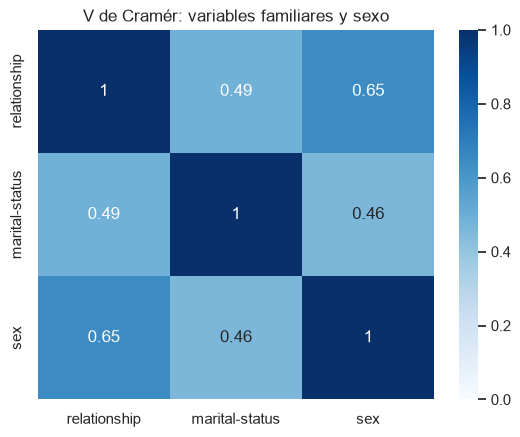

In [18]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    denominator = max(1, min(r - 1, k - 1))
    return np.sqrt((chi2 / n) / denominator)

family_cols = ['relationship', 'marital-status', 'sex']
assoc = pd.DataFrame(index=family_cols, columns=family_cols, dtype=float)
for a in family_cols:
    for b in family_cols:
        assoc.loc[a, b] = 1.0 if a == b else cramers_v(df[a], df[b])

sns.heatmap(assoc, annot=True, vmin=0, vmax=1, cmap='Blues')
plt.title('V de Cramér: variables familiares y sexo')
plt.show()


**Decisión de modelado y gobernanza**

- No eliminar automáticamente ninguna de estas variables: asociación alta no implica redundancia exacta.
- Comparar por validación cruzada un modelo completo contra modelos sin `relationship`, sin `marital-status` y sin `sex`.
- Reportar desempeño por sexo y otros grupos relevantes antes de uso operativo. Si una variable sensible no agrega valor suficiente o produce brechas injustificadas, excluirla o restringir su uso.


## 9. Relación no lineal de edad, educación y horas con el objetivo

Se agrupan valores únicamente para visualizar tasas estables. Los bins no sustituyen necesariamente las variables continuas en el modelo.


Valores válidos de income: 48790
Clases encontradas: [np.int64(0), np.int64(1)]


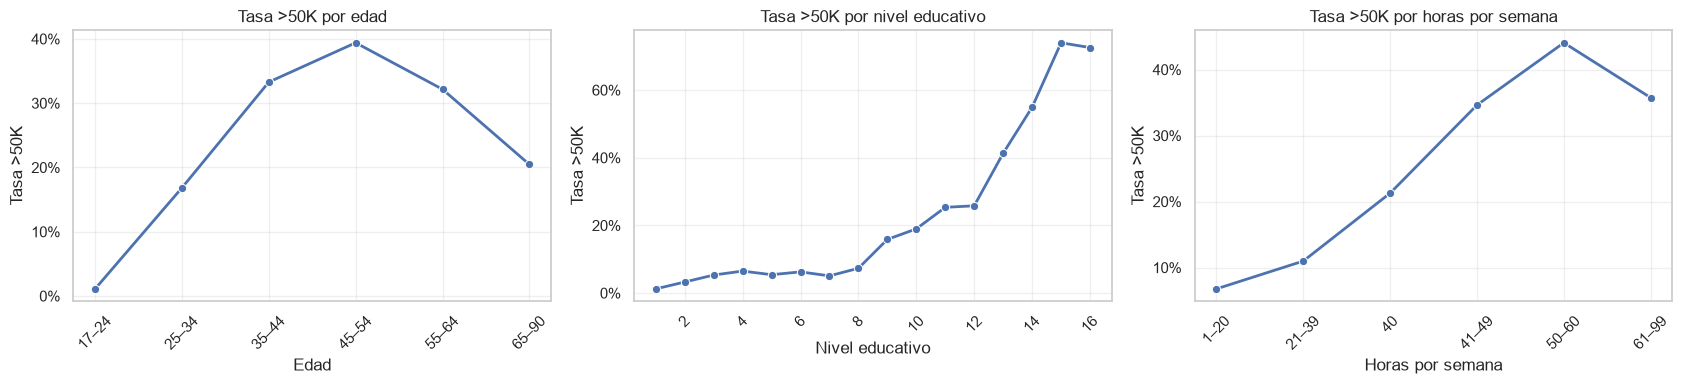

In [19]:
# Preparar la variable objetivo de forma robusta
income_limpio = df["income"].copy()

# Solo convertir si income todavía contiene etiquetas de texto
if not pd.api.types.is_numeric_dtype(income_limpio):
    income_limpio = (
        income_limpio
        .astype("string")
        .str.strip()
        .str.rstrip(".")
        .map({"<=50K": 0, ">50K": 1})
    )

income_limpio = pd.to_numeric(income_limpio, errors="coerce")

# Crear grupos ordenados para el análisis
eda_bins = pd.DataFrame({
    "age_group": pd.cut(
        df["age"],
        bins=[16, 24, 34, 44, 54, 64, 90],
        labels=["17–24", "25–34", "35–44", "45–54", "55–64", "65–90"],
        include_lowest=True
    ),
    "hours_group": pd.cut(
        df["hours-per-week"],
        bins=[0, 20, 39, 40, 49, 60, 99],
        labels=["1–20", "21–39", "40", "41–49", "50–60", "61–99"],
        include_lowest=True
    ),
    "education-num": df["education-num"],
    "income": income_limpio
})

# Comprobar que existen datos válidos
print("Valores válidos de income:", eda_bins["income"].notna().sum())
print("Clases encontradas:", sorted(eda_bins["income"].dropna().unique()))

# Crear los gráficos
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

columnas = ["age_group", "education-num", "hours_group"]
titulos = ["Edad", "Nivel educativo", "Horas por semana"]

for ax, col, title in zip(axes, columnas, titulos):
    rates = (
        eda_bins
        .dropna(subset=[col, "income"])
        .groupby(col, observed=True, sort=False)["income"]
        .agg(tasa_50k="mean", cantidad="size")
        .reset_index()
    )

    sns.lineplot(
        data=rates,
        x=col,
        y="tasa_50k",
        marker="o",
        linewidth=2,
        ax=ax
    )

    ax.set_title(f"Tasa >50K por {title.lower()}")
    ax.set_xlabel(title)
    ax.set_ylabel("Tasa >50K")
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda valor, _: f"{valor:.0%}")
    )
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Decisión de modelado**

- Conservar `age`, `education-num` y `hours-per-week`.
- No imponer linealidad sin comprobarla. Para regresión logística, comparar términos no lineales (splines o bins definidos dentro del pipeline); para árboles, conservar valores originales.
- Usar los grupos únicamente para interpretación descriptiva, evitando fuga al definir transformaciones con el conjunto de prueba.


## 10. Matriz final de decisiones

| Evidencia EDA | Decisión | Tipo | Verificación posterior |
|---|---|---|---|
| Duplicados exactos | Eliminarlos antes de dividir | Limpieza / leakage | Cero duplicados antes del split |
| Faltantes en 3 variables categóricas | Imputar moda dentro del pipeline + indicador de ausencia | Limpieza / features | Ablación de indicadores |
| Objetivo ≈ 76/24 | `stratify`, métricas por clase y prueba de pesos | Modelado | CV estratificada, PR-AUC/F1/recall |
| `education` ↔ `education-num` uno-a-uno | Eliminar `education` | Features | Confirmar mapeo en cada nueva carga |
| Capital con >90% ceros y cola larga | Indicador binario + `log1p` para modelos sensibles | Features | Comparación por CV |
| Extremos dentro del dominio | No borrarlos por IQR | Limpieza | Gates de rangos de negocio |
| Categorías raras / no vistas | Encoder robusto y agrupación aprendida en train | Modelado | Prueba con categorías nuevas |
| Variables familiares asociadas | Regularización y ablación, no borrado automático | Modelado / gobernanza | Métricas globales y por subgrupo |
| Patrones no lineales | Árboles o términos no lineales | Modelado | Comparar CV contra baseline lineal |

### Criterio de cierre del EDA

El EDA termina cuando cada hallazgo está conectado a una acción verificable. La selección definitiva de transformaciones y variables se realizará mediante validación cruzada dentro de un pipeline, manteniendo el conjunto de prueba intacto hasta la evaluación final.
